# Configuración básica (no tocar)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from abstractions.base import Function
from abstractions.functions import Variable, sin, cos, exp, ln

C:\Users\florf\AppData\Local\Temp\ipykernel_18552\3207373698.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
x = Variable()

# Implementación de métodos

In [12]:
# Implementar para hallar raíces de las derivadas, no de f

def biseccion(f: Function, a: float, b: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()  # calcula f'
    # f'(a) y f'(b) deben tener signos opuestos para garantizar que hay un cero entre ellos
    if df.eval(a) * df.eval(b) >= 0:
        raise ValueError("f'(a) y f'(b) deben tener signos opuestos.")
    for step in range(1, max_iter + 1):
        mid = (a + b) / 2  # punto medio del intervalo
        df_mid = df.eval(mid)
        # se alcanzó la precisión deseada: f' ≈ 0 o el intervalo es suficientemente pequeño
        if abs(df_mid) < tol or (b - a) / 2 < tol:
            return mid, step
        # se achica el intervalo según el signo de f' en el punto medio
        if df.eval(a) * df_mid < 0:
            b = mid
        else:
            a = mid
    # se alcanzó el máximo de iteraciones sin converger
    return (a + b) / 2, max_iter

def newton(f: Function, x0: float, tol: float = 1e-6, max_iter: int = 1000):
    df  = f.derivative()   # calcula f'
    d2f = df.derivative()  # calcula f''
    xn  = x0
    for step in range(1, max_iter + 1):
        df_val  = df.eval(xn)
        d2f_val = d2f.eval(xn)
        # se alcanzó la precisión deseada: f' ≈ 0
        if abs(df_val) < tol:
            return xn, step
        # si f'' ≈ 0 no se puede dividir, el método no puede continuar
        if abs(d2f_val) < 1e-12:
            raise ValueError(f"f''({xn}) ≈ 0: Newton no puede continuar.")
        xn = xn - df_val / d2f_val  # actualización: x = x - f'(x)/f''(x)
    # se alcanzó el máximo de iteraciones sin converger
    return xn, max_iter

def descenso_gradiente(f: Function, x0: float, lr: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()  # calcula f'
    xn = x0
    for step in range(1, max_iter + 1):
        grad = df.eval(xn)
        # se alcanzó la precisión deseada: f' ≈ 0
        if abs(grad) < tol:
            return xn, step
        xn = xn - lr * grad  # actualización: x = x - lr * f'(x)
    # se alcanzó el máximo de iteraciones sin converger
    return xn, max_iter

### Prueba de métodos

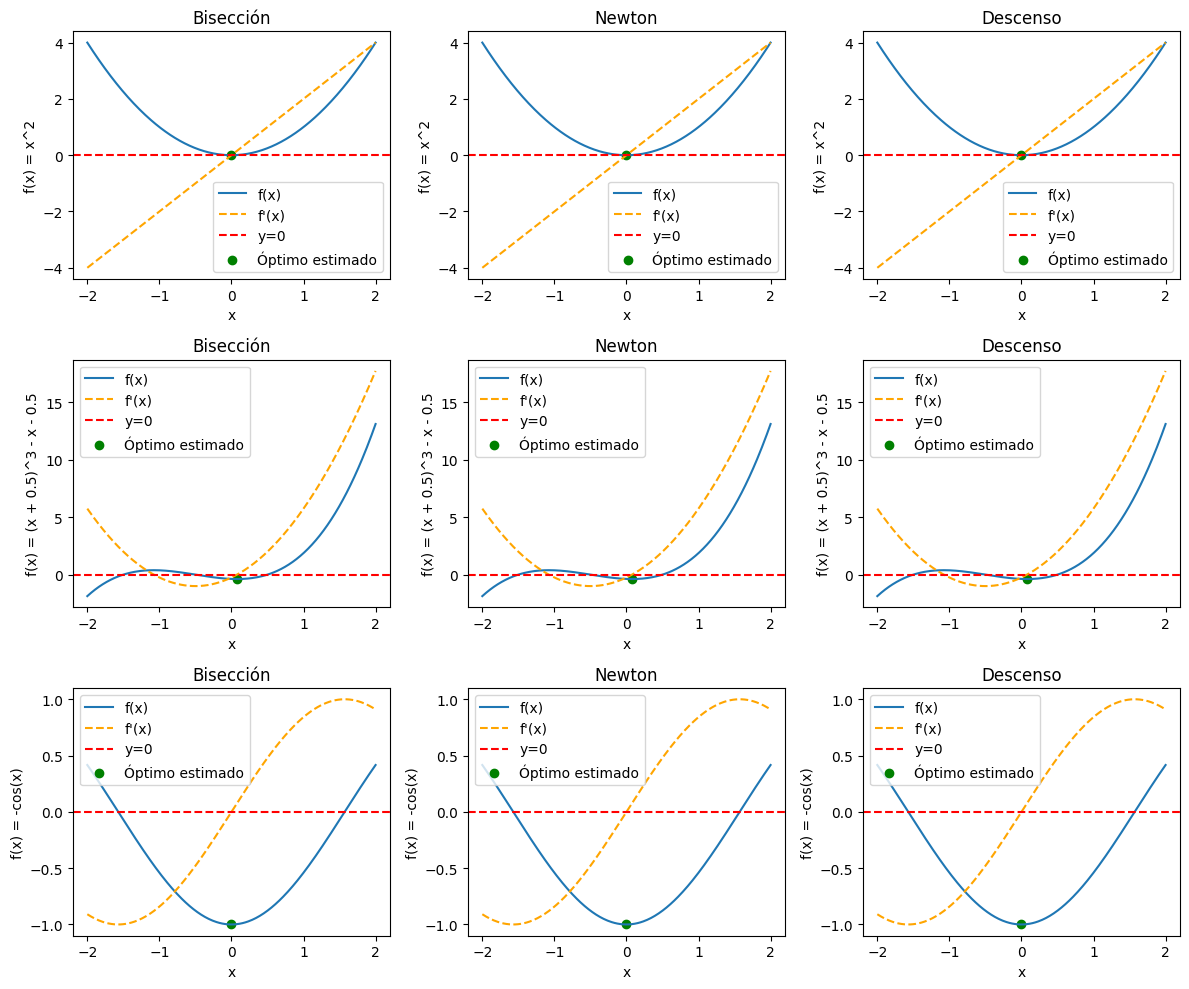

In [13]:
f1 = x**2
f2 = (x + 0.5)**3 - x - 0.5
f3 = -cos(x)

functions = [f1, f2, f3]

methods = [biseccion, newton, descenso_gradiente]
# Recomendación: exploren parámetros en esta etapa para ver distintos comportamientos.
parameters = [{"a":-1, "b":1}, {"x0": 1}, {"x0": 1, "lr": 1e-2}]

y_labels = ["f(x) = x^2", "f(x) = (x + 0.5)^3 - x - 0.5", "f(x) = -cos(x)"]
titles = ["Bisección", "Newton", "Descenso"]

lp = np.linspace(-2, 2, 300)

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for i, f in enumerate(functions):
    for j, m in enumerate(methods):
        ax = axes[i, j]
        # labels ejes
        ax.set_xlabel("x")
        ax.set_ylabel(y_labels[i])

        # métodos
        method = methods[j]
        params = parameters[j] 
        res, step = method(f, **params)

        # graficas
        ax.plot(lp, np.array(list(map(lambda v: f.eval(v), lp))))
        ax.plot(lp, np.array(list(map(lambda v: f.derivative().eval(v), lp))), linestyle="--", color="orange")
        ax.axhline(0, linestyle="--", color="red")
        ax.scatter(res, f.eval(res), color="green")

        ax.plot()
        ax.legend([f"f(x)", "f'(x)", "y=0", "Óptimo estimado"])
        ax.set_title(titles[j])

plt.tight_layout()
plt.savefig("graficas/seccion2_verificacion.png", dpi=150, bbox_inches="tight")
plt.show()

# Aplicación a función no trivial

In [6]:
f = x**2 + 2*sin(3*x)

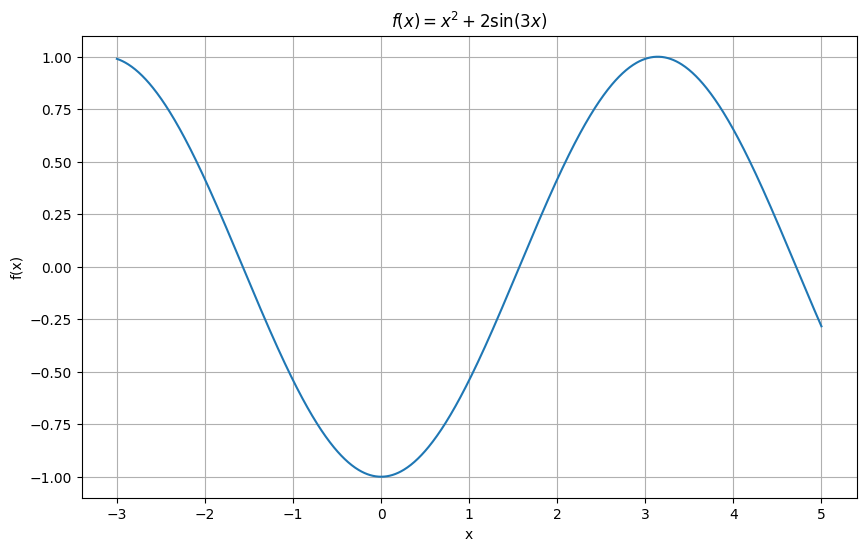

In [17]:
# Grafica de la función
lp = np.linspace(-3, 5, 1000)

plt.figure(figsize=(10,6))
plt.plot(lp, [f.eval(v) for v in lp])

plt.grid(True)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(r"$f(x)=x^2+2\sin(3x)$")
plt.savefig("graficas/seccion3_funcNoTrivial.png", dpi=150, bbox_inches="tight")

plt.show()

In [28]:
# Evaluación de métodos y generación de tablas
results = []

# ------------------
# BISECCIÓN
# ------------------
for a, b in [(-2,1), (-1,0), (1,2)]:
    try:
        root, it = biseccion(f, a, b)
        results.append({
            "Método": "Bisección",
            "Inicial": f"[{a},{b}]",
            "Resultado": root,
            "f(x)": f.eval(root),
            "Iteraciones": it
        })
    except Exception as e:

        results.append({
            "Método": "Bisección",
            "Inicial": f"[{a},{b}]",
            "Resultado": str(e),
            "f(x)": None,
            "Iteraciones": None
        })
# ------------------
# NEWTON
# ------------------
for x0 in [-2, -1, 4]:
    try:
        root, it = newton(f, x0)
        results.append({
            "Método": "Newton",
            "Inicial": x0,
            "Resultado": root,
            "f(x)": f.eval(root),
            "Iteraciones": it
        })
    except Exception as e:
        results.append({
            "Método": "Newton",
            "Inicial": x0,
            "Resultado": str(e),
            "f(x)": None,
            "Iteraciones": None
        })
# ------------------
# DESCENSO POR GRADIENTE
# ------------------
for x0 in [-3, 0.585, 4]:
    root, it = descenso_gradiente(
        f,
        x0,
        lr=0.05
    )
    results.append({
        "Método": "Gradiente",
        "Inicial": x0,
        "Resultado": root,
        "f(x)": f.eval(root),
        "Iteraciones": it
    })
tabla = pd.DataFrame(results)
tabla.to_csv(
    "tablas/evaluacion_metodos.csv",
    index=False
)

tabla.to_latex(
    "tablas/evaluacion_metodos.tex",
    index=False,
    float_format="%.6f"
)
tabla

,Método,Inicial,Resultado,f(x),Iteraciones
0,Bisección,"[-2,1]",0.000001,-1.0,20.0
1,Bisección,"[-1,0]",f'(a) y f'(b) deben tener signos opuestos.,NaN,NaN
2,Bisección,"[1,2]",f'(a) y f'(b) deben tener signos opuestos.,NaN,NaN
3,Newton,-2,-3.141593,1.0,6.0
4,Newton,-1,-0.0,-1.0,5.0
5,Newton,4,3.141592,1.0,4.0
6,Gradiente,-3,-0.000001,-1.0,339.0
7,Gradiente,0.585,0.000001,-1.0,261.0
8,Gradiente,4,6.283184,-1.0,300.0


In [27]:
#Comparación de los learning rates para el método de descenso por gradiente
resultados_gradiente = []
learning_rates = [0.01, 0.05, 0.1]

for lr in learning_rates:
    print(f"\nLearning rate = {lr}")
    for x0 in [-3, 0.585, 4]:
        root, it = descenso_gradiente(
            f,
            x0,
            lr=lr
        )
        resultados_gradiente.append({
            "learning_rate": lr,
            "x0": x0,
            "x_final": root,
            "f(x_final)": f.eval(root),
            "iteraciones": it
        })
df = pd.DataFrame(resultados_gradiente)  
df.to_csv(
    "tablas/learning_rates_gradiente.csv",
    index=False
)

df.to_latex(
    "tablas/learning_rates_gradiente.tex",
    index=False,
    float_format="%.6f"
)

df


Learning rate = 0.01

Learning rate = 0.05

Learning rate = 0.1


,learning_rate,x0,x_final,f(x_final),iteraciones
0,0.01,-3.000,-1.250442e-03,-0.999999,1000
1,0.01,0.585,2.601238e-05,-1.000000,1000
2,0.01,4.000,6.282995e+00,-1.000000,1000
3,0.05,-3.000,-9.555621e-07,-1.000000,339
4,0.05,0.585,9.748351e-07,-1.000000,261
5,0.05,4.000,6.283184e+00,-1.000000,300
6,0.10,-3.000,-9.492407e-07,-1.000000,167
7,0.10,0.585,9.347976e-07,-1.000000,128
8,0.10,4.000,6.283184e+00,-1.000000,148


## Bonus Sección 3
Para esta parte decidimos re-hacer las funciones usadas en la sección anterior, ya que ahora necesitamos más parámetros. Nos pareció más ordenado de esta manera.

### Métodos editados

In [14]:
def biseccion_historial(f: Function, a: float, b: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    if df.eval(a) * df.eval(b) >= 0:
        raise ValueError("f'(a) y f'(b) deben tener signos opuestos.")
    historial = []
    
    for step in range(1, max_iter + 1):
        mid = (a + b) / 2
        historial.append(mid)
        df_mid = df.eval(mid)
        if abs(df_mid) < tol or (b - a) / 2 < tol:
            return mid, step, historial
        if df.eval(a) * df_mid < 0:
            b = mid
        else:
            a = mid
    return (a + b) / 2, max_iter, historial

def newton_historial(f: Function, x0: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    d2f = df.derivative()
    xn = x0
    historial = [xn]

    for step in range(1, max_iter + 1):
        df_val = df.eval(xn)
        if abs(df_val) < tol:
            return xn, step, historial
        d2f_val = d2f.eval(xn)
        if abs(d2f_val) < 1e-12:
            raise ValueError(
                f"f''({xn}) ≈ 0: Newton no puede continuar."
            )
        xn = xn - df_val / d2f_val
        historial.append(xn)

    return xn, max_iter, historial

def descenso_gradiente_historial(f: Function, x0: float, lr: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    xn = x0
    historial = [xn]

    for step in range(1, max_iter + 1):
        grad = df.eval(xn)
        if abs(grad) < tol:
            return xn, step, historial
        xn = xn - lr * grad
        historial.append(xn)

    return xn, max_iter, historial

### Visualización de la trayectoria

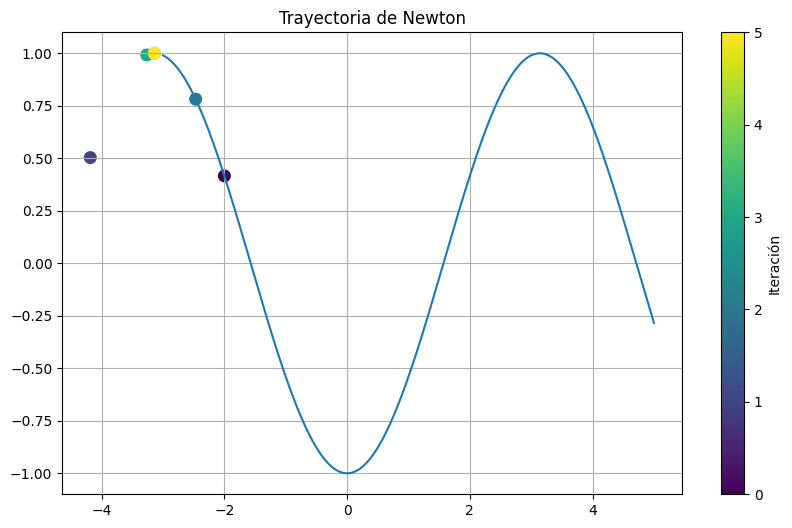

In [18]:
#Con Newton
raiz, it, historial = newton_historial(f, -2)

xs = np.linspace(-3, 5, 1000)
ys = [f.eval(x) for x in xs]

plt.figure(figsize=(10,6))
plt.plot(xs, ys, label="f(x)")

colores = np.arange(len(historial))

plt.scatter(
    historial,
    [f.eval(x) for x in historial],
    c=colores,
    cmap="viridis",
    s=70
)

plt.colorbar(label="Iteración")

plt.title("Trayectoria de Newton")
plt.grid(True)
plt.savefig("graficas/seccion3_BONUSNewton.png", dpi=150, bbox_inches="tight")

plt.show()

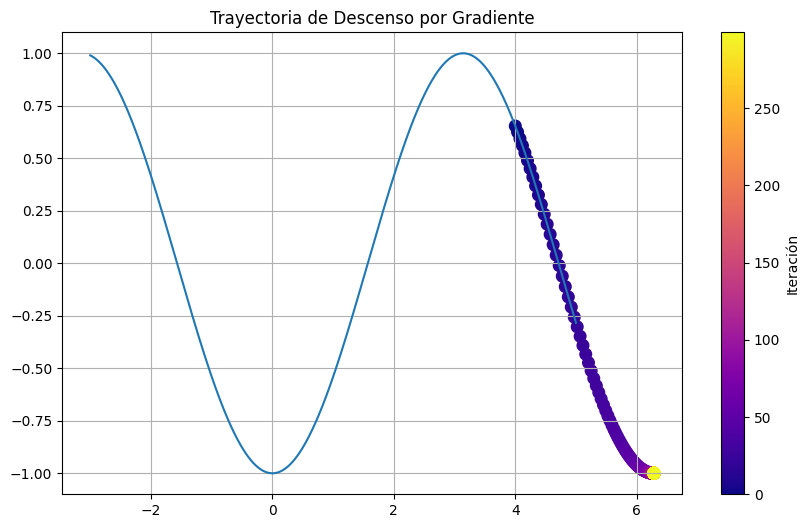

In [19]:
#Con descenso por gradiente
raiz, it, historial = descenso_gradiente_historial(f,x0=4,lr=0.05)

xs = np.linspace(-3, 5, 1000)
ys = [f.eval(x) for x in xs]

plt.figure(figsize=(10,6))
plt.plot(xs, ys)

plt.scatter(
    historial,
    [f.eval(x) for x in historial],
    c=np.arange(len(historial)),
    cmap="plasma",
    s=70
)

plt.colorbar(label="Iteración")

plt.title("Trayectoria de Descenso por Gradiente")
plt.grid(True)
plt.savefig("graficas/seccion3_BONUSDescensoGradiente.png", dpi=150, bbox_inches="tight")

plt.show()

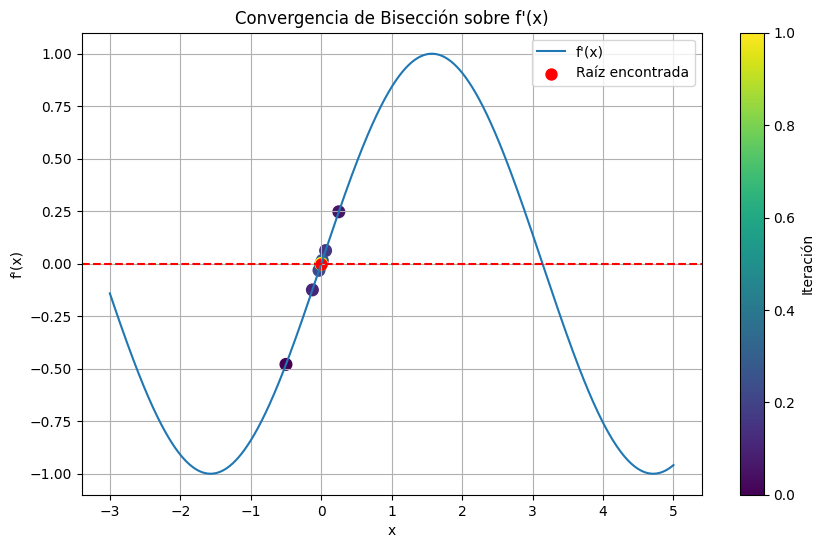

In [22]:
#Con bisección
df = f.derivative()
raiz, it, historial = biseccion_historial(f, -2, 1)
xs = np.linspace(-3, 5, 1000)

plt.figure(figsize=(10,6))

plt.plot(xs, [df.eval(x) for x in xs], label="f'(x)")

plt.axhline(0, color="red", linestyle="--")
plt.scatter(historial, [df.eval(x) for x in historial], c=np.arange(len(historial)), cmap="viridis", s=70)

plt.scatter(raiz, 0, marker=".", s=250, label="Raíz encontrada", color="red")

plt.colorbar(label="Iteración")

plt.title("Convergencia de Bisección sobre f'(x)")
plt.xlabel("x")
plt.ylabel("f'(x)")
plt.grid(True)
plt.legend()
plt.savefig("graficas/seccion3_BONUSBiseccion.png", dpi=150, bbox_inches="tight")

plt.show()

# Ajuste de datos

In [50]:
df_linear = pd.read_csv("datasets/linear_model.csv")
df_exp = pd.read_csv("datasets/exp_model.csv")
df_sin = pd.read_csv("datasets/sin_model.csv")

w = Variable()

In [ ]:
# Genere la función de pérdida

In [ ]:
# Optimice la función de pérdida

In [ ]:
# Grafique datos y ajuste

# BONUS: